# FActScore-Turbo Baseline — Results Analysis

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve

# Project root on sys.path so local imports work in notebook context.
PROJECT_ROOT = Path("__file__").resolve().parents[1]
RESULTS_DIR  = PROJECT_ROOT / "experiments" / "factscore_turbo_baseline" / "results"

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Results dir:", RESULTS_DIR)

Results dir: /Users/vekshinkir/Projects/context_hallucination_prevention/experiments/factscore_turbo_baseline/results


In [2]:
df = pd.read_csv(RESULTS_DIR / "results.csv")
with open(RESULTS_DIR / "results.json") as fh:
    metrics = json.load(fh)

print(f"Loaded {len(df)} rows — columns: {list(df.columns)}")
df.head(3)

Loaded 200 rows — columns: ['context', 'question', 'response', 'is_hallucinated', 'task_type', 'gen_model', 'source', 'factscore', 'n_facts', 'n_supported', 'score_error']


,context,question,response,is_hallucinated,task_type,gen_model,source,factscore,n_facts,n_supported,score_error
0,A natural gas line explosion at a law enforcem...,Summarize the following news within 66 words:,A natural gas line explosion occurred at a law...,True,Summary,mistral-7B-instruct,ragtruth,0.857143,7,6,NaN
1,"{'name': ""Crazy Jim's Tacos Y Más"", 'address':...",Instruction:\nWrite an objective overview abou...,Crazy Jim's Tacos Y Más is a popular Tex-Mex a...,True,Data2txt,llama-2-70b-chat,ragtruth,0.846154,13,11,NaN
2,Bombing of Gaza is continuing\nA HIGH-RISE bui...,Summarize the following news within 99 words:,The ongoing conflict between Israel and Hamas ...,True,Summary,mistral-7B-instruct,ragtruth,1.000000,8,8,NaN


In [3]:
# Key metrics summary.
summary_keys = [
    "n_samples", "roc_auc", "optimal_f1", "optimal_threshold",
    "optimal_precision", "optimal_recall",
    "avg_factscore", "std_factscore", "avg_n_facts",
]
for k in summary_keys:
    v = metrics.get(k)
    fmt = f"{v:.4f}" if isinstance(v, float) else str(v)
    print(f"  {k:<25s} {fmt}")

  n_samples                 200
  roc_auc                   0.7056
  optimal_f1                0.6986
  optimal_threshold         0.9167
  optimal_precision         0.6697
  optimal_recall            0.7300
  avg_factscore             0.8707
  std_factscore             0.1377
  avg_n_facts               9.6900


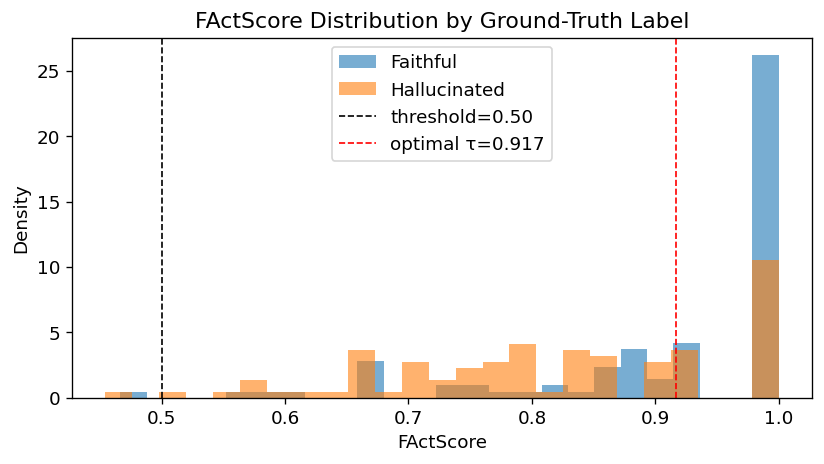

In [4]:
# FActScore distribution by ground-truth label.
fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in df.groupby("is_hallucinated"):
    ax.hist(
        grp["factscore"].dropna(),
        bins=25,
        alpha=0.6,
        density=True,
        label="Hallucinated" if label else "Faithful",
    )
ax.axvline(0.5,  color="black",  linestyle="--", lw=1, label="threshold=0.50")
ax.axvline(metrics["optimal_threshold"], color="red", linestyle="--", lw=1,
           label=f"optimal τ={metrics['optimal_threshold']:.3f}")
ax.set_xlabel("FActScore")
ax.set_ylabel("Density")
ax.set_title("FActScore Distribution by Ground-Truth Label")
ax.legend()
fig.tight_layout()
plt.show()

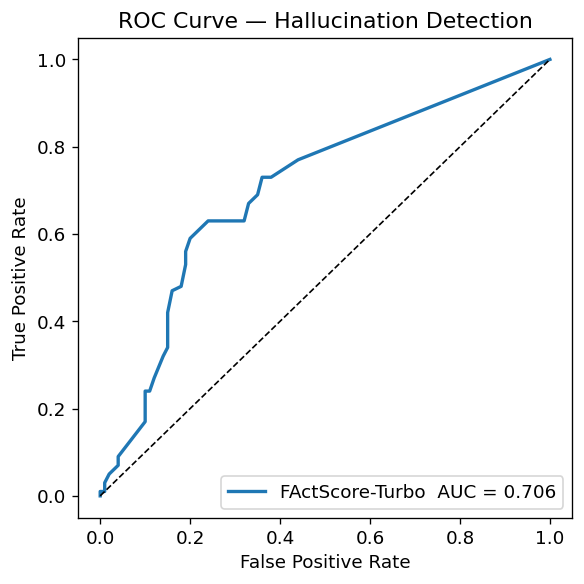

In [5]:
# ROC curve.
valid = df.dropna(subset=["factscore", "is_hallucinated"])
y_true  = valid["is_hallucinated"].astype(int).values
y_score = (1 - valid["factscore"]).values

fpr, tpr, _ = roc_curve(y_true, y_score)
auc_val = metrics["roc_auc"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, label=f"FActScore-Turbo  AUC = {auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Hallucination Detection")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

/var/folders/pk/mvk744050bx3spqxf0dhfp4m0000gn/T/ipykernel_97318/3537759491.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=task_df, x="task_type", y="f1", ax=ax, palette="viridis")


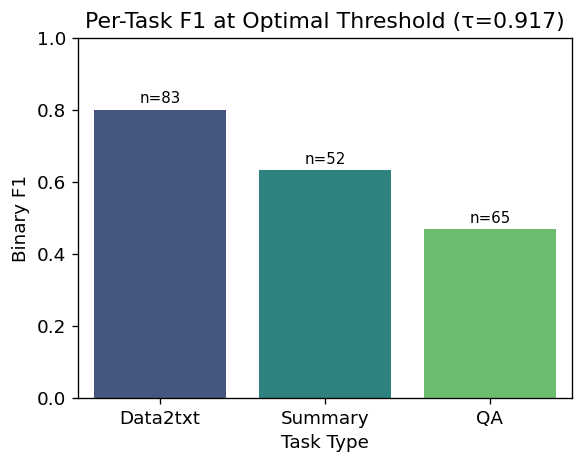

In [6]:
# Per-task F1 bar chart.
from sklearn.metrics import f1_score

tau = metrics["optimal_threshold"]
records = []
for task, grp in df.groupby("task_type"):
    g = grp.dropna(subset=["factscore", "is_hallucinated"])
    if len(g) < 5:
        continue
    yt = g["is_hallucinated"].astype(int).values
    yp = (g["factscore"] < tau).astype(int).values
    records.append({"task_type": task, "f1": f1_score(yt, yp, zero_division=0), "n": len(g)})

task_df = pd.DataFrame(records).sort_values("f1", ascending=False)

fig, ax = plt.subplots(figsize=(max(5, len(task_df) * 1.4), 4))
bars = sns.barplot(data=task_df, x="task_type", y="f1", ax=ax, palette="viridis")
for p, row in zip(ax.patches, task_df.itertuples()):
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
            f"n={row.n}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1)
ax.set_xlabel("Task Type")
ax.set_ylabel("Binary F1")
ax.set_title(f"Per-Task F1 at Optimal Threshold (τ={tau:.3f})")
fig.tight_layout()
plt.show()

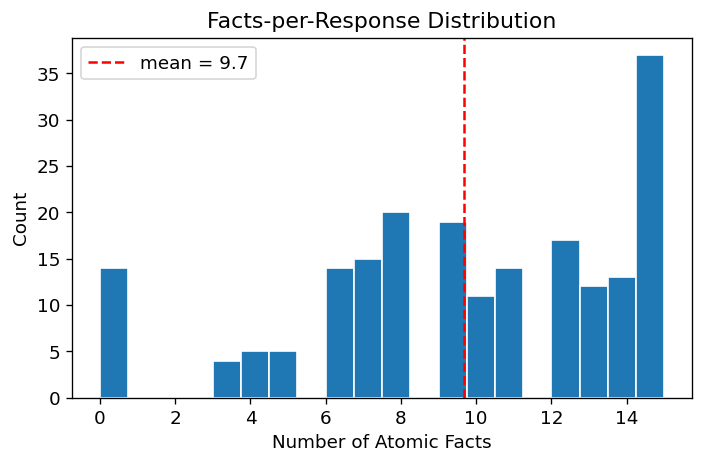

In [7]:
# Facts-per-response distribution.
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["n_facts"].dropna(), bins=20, edgecolor="white")
ax.axvline(metrics["avg_n_facts"], color="red", linestyle="--", lw=1.5,
           label=f"mean = {metrics['avg_n_facts']:.1f}")
ax.set_xlabel("Number of Atomic Facts")
ax.set_ylabel("Count")
ax.set_title("Facts-per-Response Distribution")
ax.legend()
fig.tight_layout()
plt.show()

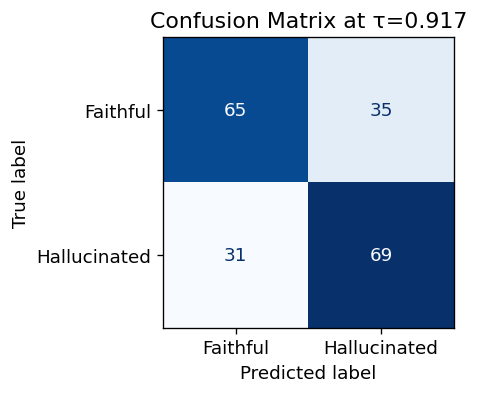

In [8]:
# Confusion matrix at optimal threshold.
tau = metrics["optimal_threshold"]
valid = df.dropna(subset=["factscore", "is_hallucinated"])
y_true = valid["is_hallucinated"].astype(int).values
y_pred = (valid["factscore"] < tau).astype(int).values

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Faithful", "Hallucinated"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion Matrix at τ={tau:.3f}")
fig.tight_layout()
plt.show()